In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pysr import PySRRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [169]:
# Load data
# File paths
file_path1 = '/Users/rww21/Documents/Code/IMC3/Round 5/Data/round-5-island-data-bottle/observations_round_5_day_2.csv'
file_path2 = '/Users/rww21/Documents/Code/IMC3/Round 5/Data/round-5-island-data-bottle/observations_round_5_day_3.csv'
file_path3 = '/Users/rww21/Documents/Code/IMC3/Round 5/Data/round-5-island-data-bottle/observations_round_5_day_4.csv'

# Read the data from each file
df1 = pd.read_csv(file_path1, sep=',')
df2 = pd.read_csv(file_path2, sep=',')
df3 = pd.read_csv(file_path3, sep=',')

# Concatenate the dataframes
observation = pd.concat([df1, df2, df3], ignore_index=True)

# Calculate the new timestamp values
new_timestamps = range(0, len(observation) * 100, 100)
observation['timestamp'] = new_timestamps  # Replace the 'timestamp' column
observation = observation.reset_index(drop=True)

observation

,timestamp,bidPrice,askPrice,transportFees,exportTariff,importTariff,sugarPrice,sunlightIndex
0,0,657.0,658.5,1.4,10.5,-4.0,209.000000,65.00
1,100,660.5,662.0,1.4,10.5,-4.0,209.299299,65.00
2,200,664.0,665.5,1.4,10.5,-4.0,209.467113,65.00
3,300,669.0,670.5,1.4,10.5,-4.0,209.525592,65.00
4,400,673.5,675.0,1.4,10.5,-4.0,209.597333,65.00
...,...,...,...,...,...,...,...,...
29995,2999500,745.0,746.5,1.6,7.5,-4.0,206.028012,59.94
29996,2999600,741.0,742.5,1.6,7.5,-4.0,205.991170,59.95
29997,2999700,744.5,746.0,1.6,7.5,-4.0,206.053141,59.96
29998,2999800,744.0,745.5,1.6,7.5,-4.0,205.751795,59.98


In [171]:
# Load data
# File paths
file_path1 = '/Users/rww21/Documents/Code/IMC3/Round 5/Data/round-5-island-data-bottle/prices_round_5_day_2.csv'
file_path2 = '/Users/rww21/Documents/Code/IMC3/Round 5/Data/round-5-island-data-bottle/prices_round_5_day_3.csv'
file_path3 = '/Users/rww21/Documents/Code/IMC3/Round 5/Data/round-5-island-data-bottle/prices_round_5_day_4.csv'

# Read the data from each file
df1 = pd.read_csv(file_path1, sep=';')
df2 = pd.read_csv(file_path2, sep=';')
df3 = pd.read_csv(file_path3, sep=';')

# Concatenate the dataframes
prices = pd.concat([df1, df2, df3], ignore_index=True)

# Calculate the new timestamp values
# new_timestamps = range(0, len(prices) * 100, 100)
# prices['timestamp'] = new_timestamps  # Replace the 'timestamp' column
# prices = prices.reset_index(drop=True)

prices

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,PICNIC_BASKET2,30094.0,11.0,30093.0,27.0,NaN,NaN,30099.0,1.0,30100.0,37.0,NaN,NaN,30096.5,0.0
1,2,0,VOLCANIC_ROCK_VOUCHER_9750,469.0,11.0,NaN,NaN,NaN,NaN,470.0,11.0,NaN,NaN,NaN,NaN,469.5,0.0
2,2,0,RAINFOREST_RESIN,9992.0,35.0,NaN,NaN,NaN,NaN,10008.0,35.0,NaN,NaN,NaN,NaN,10000.0,0.0
3,2,0,VOLCANIC_ROCK_VOUCHER_9500,718.0,11.0,NaN,NaN,NaN,NaN,719.0,11.0,NaN,NaN,NaN,NaN,718.5,0.0
4,2,0,VOLCANIC_ROCK,10218.0,150.0,10217.0,64.0,NaN,NaN,10219.0,150.0,10220.0,64.0,NaN,NaN,10218.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449995,4,999900,VOLCANIC_ROCK_VOUCHER_10500,0.0,11.0,NaN,NaN,NaN,NaN,2.0,11.0,NaN,NaN,NaN,NaN,1.0,0.0
449996,4,999900,DJEMBES,13409.0,30.0,13408.0,50.0,NaN,NaN,13410.0,80.0,NaN,NaN,NaN,NaN,13409.5,0.0
449997,4,999900,VOLCANIC_ROCK,10104.0,146.0,NaN,NaN,NaN,NaN,10106.0,104.0,10107.0,42.0,NaN,NaN,10105.0,0.0
449998,4,999900,RAINFOREST_RESIN,9992.0,35.0,NaN,NaN,NaN,NaN,9999.0,1.0,10008.0,35.0,NaN,NaN,9995.5,0.0


In [172]:
# Load data
# File paths
file_path1 = '/Users/rww21/Documents/Code/IMC3/Round 5/Data/round-5-island-data-bottle/trades_round_5_day_2.csv'
file_path2 = '/Users/rww21/Documents/Code/IMC3/Round 5/Data/round-5-island-data-bottle/trades_round_5_day_3.csv'
file_path3 = '/Users/rww21/Documents/Code/IMC3/Round 5/Data/round-5-island-data-bottle/trades_round_5_day_4.csv'

# Read the data from each file
df1 = pd.read_csv(file_path1, sep=';')
df2 = pd.read_csv(file_path2, sep=';')
df3 = pd.read_csv(file_path3, sep=';')

# Concatenate the dataframes
trades = pd.concat([df1, df2, df3], ignore_index=True)

# Calculate the new timestamp values
# new_timestamps = range(0, len(trades) * 100, 100)
# trades['timestamp'] = new_timestamps  # Replace the 'timestamp' column
# trades = trades.reset_index(drop=True)

trades

,timestamp,buyer,seller,symbol,currency,price,quantity
0,0,Caesar,Paris,CROISSANTS,SEASHELLS,4265.0,8
1,100,Charlie,Paris,RAINFOREST_RESIN,SEASHELLS,9999.0,1
2,200,Paris,Caesar,CROISSANTS,SEASHELLS,4266.0,8
3,200,Paris,Caesar,JAMS,SEASHELLS,6520.0,7
4,200,Paris,Charlie,KELP,SEASHELLS,2046.0,1
...,...,...,...,...,...,...,...
53472,999600,Caesar,Pablo,VOLCANIC_ROCK,SEASHELLS,10104.0,2
53473,999700,Charlie,Paris,KELP,SEASHELLS,2011.0,1
53474,999700,Charlie,Paris,SQUID_INK,SEASHELLS,1899.0,1
53475,999700,Peter,Caesar,VOLCANIC_ROCK,SEASHELLS,10107.0,10


['Caesar', 'Camilla', 'Charlie', 'Gary', 'Gina', 'Olivia', 'Pablo', 'Paris', 'Penelope', 'Peter']


<Axes: xlabel='buyer'>

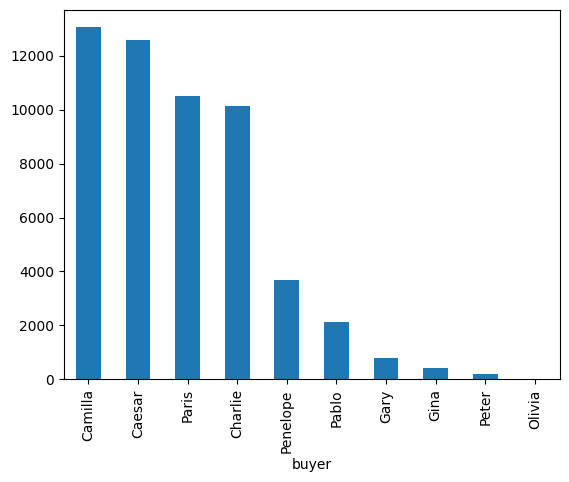

In [173]:
# Visualise buyer data
print(sorted(trades['buyer'].unique()))
trades['buyer'].value_counts().plot(kind='bar')

['Caesar', 'Camilla', 'Charlie', 'Gary', 'Gina', 'Olga', 'Olivia', 'Pablo', 'Paris', 'Penelope', 'Peter']


<Axes: xlabel='seller'>

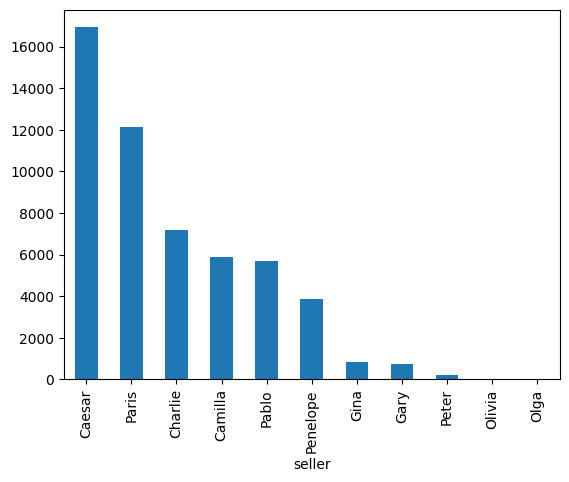

In [174]:
# Visualise seller data
print(sorted(trades['seller'].unique()))
trades['seller'].value_counts().plot(kind='bar')

In [175]:
# PnL per trade - Calculate value of each trade
trades['trade_value'] = trades['price'] * trades['quantity']
trades['seller_pnl'] = trades['trade_value']
trades['buyer_pnl'] = -trades['trade_value']

# Calculate PnL for each buyer and seller
buyer_pnl = trades.groupby('buyer')['buyer_pnl'].sum()  # PnL from buying
seller_pnl = trades.groupby('seller')['seller_pnl'].sum()  # PnL from selling
total_pnl = pd.concat([buyer_pnl, seller_pnl], axis=1).fillna(0)
total_pnl['net_pnl'] = total_pnl['seller_pnl'] + total_pnl['buyer_pnl']

total_pnl


,buyer_pnl,seller_pnl,net_pnl
Caesar,-431079150.0,337006779.0,-94072371.0
Camilla,-256890232.0,265835611.0,8945379.0
Charlie,-172996471.0,139436130.0,-33560341.0
Gary,-23404263.0,23622426.0,218163.0
Gina,-11316696.0,18584568.0,7267872.0
Olivia,-210867.0,220019.0,9152.0
Pablo,-109421572.0,212656202.0,103234630.0
Paris,-172655974.0,179854582.0,7198608.0
Penelope,-202559579.0,201369790.0,-1189789.0
Peter,-14496938.0,16427230.0,1930292.0


<Axes: >

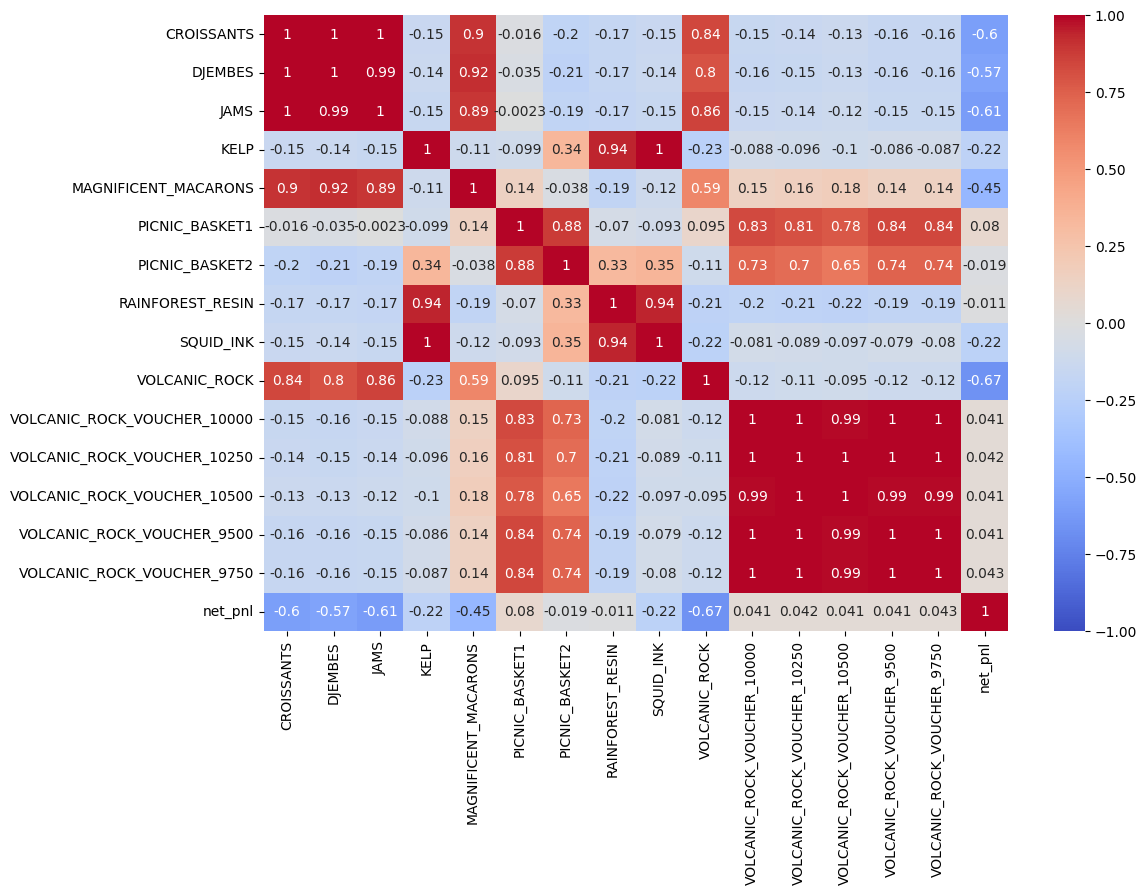

In [177]:
# Group trades by trader and product - BUYER
trader_product = trades.groupby(['buyer', 'symbol'])['trade_value'].sum().unstack().fillna(0)
# Concat with pnl
trader_product = trader_product.merge(total_pnl['net_pnl'], left_index=True, right_index=True)

fig, ax = plt.subplots(figsize=(12, 8))
# Plot heatmap
sns.heatmap(trader_product.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, ax=ax)

<Axes: >

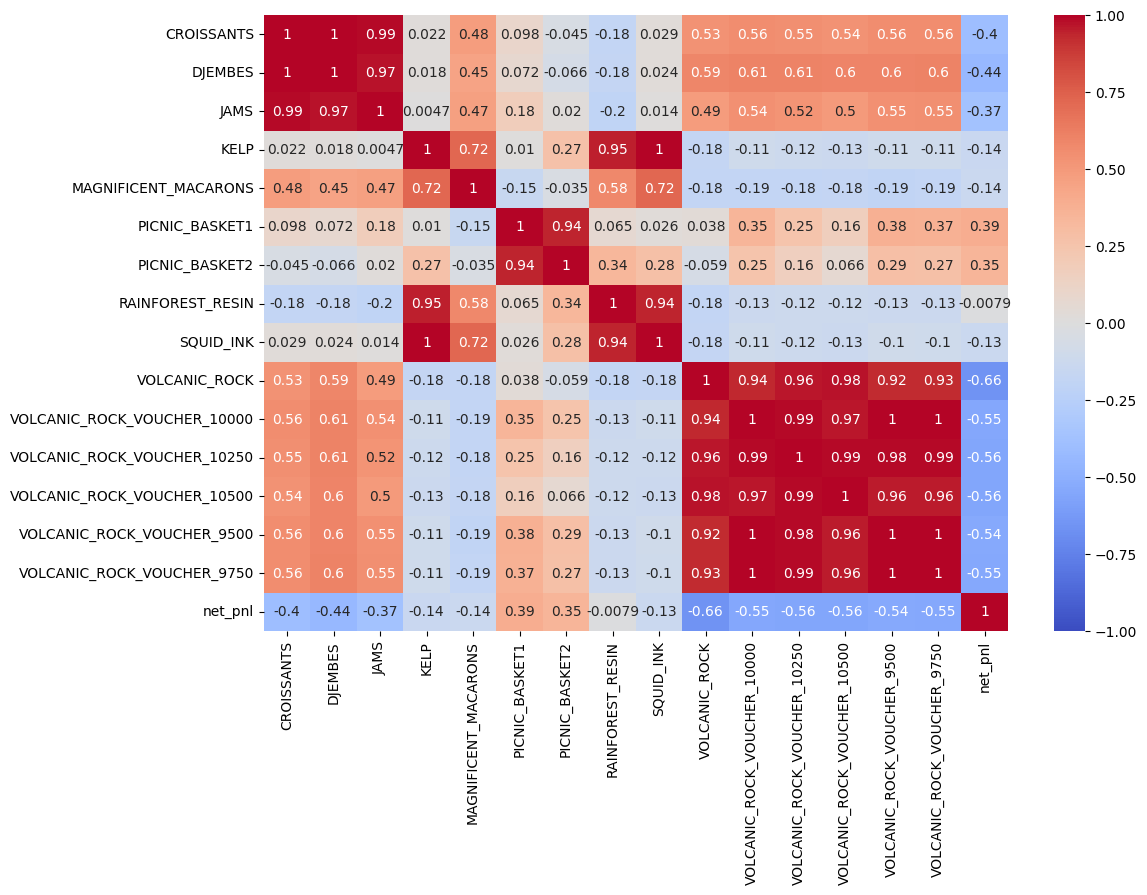

In [178]:
# Group trades by trader and product - SELLER
trader_product = trades.groupby(['seller', 'symbol'])['trade_value'].sum().unstack().fillna(0)
# Concat with pnl
trader_product = trader_product.merge(total_pnl['net_pnl'], left_index=True, right_index=True)

fig, ax = plt.subplots(figsize=(12, 8))
# Plot heatmap
sns.heatmap(trader_product.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, ax=ax)

In [179]:
price_stats = trades.groupby('symbol')['price'].agg(['mean', 'min', 'max'])
price_stats

,mean,min,max
symbol,,,
CROISSANTS,4265.945424,4227.0,4314.0
DJEMBES,13342.252652,13249.0,13496.0
JAMS,6485.514431,6411.0,6553.0
KELP,2035.113000,2006.0,2053.0
MAGNIFICENT_MACARONS,708.806871,535.0,963.0
PICNIC_BASKET1,58365.463710,58069.0,58974.0
PICNIC_BASKET2,30109.612422,29924.0,30415.0
RAINFOREST_RESIN,10000.066391,9992.0,10008.0
SQUID_INK,1880.916045,1760.0,2050.0


In [180]:
buy_price = trades.groupby(['buyer', 'symbol'])['price'].mean().unstack()
sell_price = trades.groupby(['seller', 'symbol'])['price'].mean().unstack()
spread = sell_price - buy_price
spread

symbol,CROISSANTS,DJEMBES,JAMS,KELP,MAGNIFICENT_MACARONS,PICNIC_BASKET1,PICNIC_BASKET2,RAINFOREST_RESIN,SQUID_INK,VOLCANIC_ROCK,VOLCANIC_ROCK_VOUCHER_10000,VOLCANIC_ROCK_VOUCHER_10250,VOLCANIC_ROCK_VOUCHER_10500,VOLCANIC_ROCK_VOUCHER_9500,VOLCANIC_ROCK_VOUCHER_9750
Caesar,3.118652,1.607229,-0.114355,-0.159488,-14.694352,2.562592,8.875884,2.915306,1.473723,1.446688,-5.867491,-1.129916,0.405068,-2.709483,-3.634098
Camilla,17.288690,-28.945289,3.181282,2.255370,2.157512,2.023881,5.091653,6.000000,-1.774134,NaN,28.649328,19.903111,1.448195,-3.954481,-3.736587
Charlie,NaN,NaN,NaN,2.651596,9.853846,-62.607843,2.196051,11.362425,6.056855,NaN,NaN,NaN,NaN,NaN,NaN
Gary,NaN,NaN,NaN,-3.140728,NaN,NaN,NaN,-13.390152,-12.136208,NaN,NaN,NaN,NaN,NaN,NaN
Gina,NaN,NaN,NaN,-3.531530,NaN,NaN,NaN,-4.635600,1.912366,NaN,NaN,NaN,NaN,NaN,NaN
Olga,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Olivia,58.333333,NaN,NaN,20.666667,NaN,NaN,NaN,NaN,160.750000,NaN,NaN,NaN,NaN,NaN,NaN
Pablo,NaN,NaN,NaN,-1.473862,NaN,-1.039893,-5.844013,-7.583725,-0.579232,2.816327,-30.687500,-2.401149,0.055928,2.620115,-31.407834
Paris,-2.902719,-0.273811,0.177246,-2.236919,-5.102855,NaN,NaN,-7.910812,-4.123585,NaN,NaN,NaN,NaN,NaN,NaN
Penelope,NaN,NaN,NaN,-1.791805,NaN,-0.515009,-7.312526,-13.463009,-2.886540,NaN,-4.683571,-1.552643,0.174938,-1.296543,-2.356730


In [181]:
def trader_stats(trader_name, df=trades):
    # Filter trades
    buys = df[df['buyer'] == trader_name].copy()
    sells = df[df['seller'] == trader_name].copy()

    # Aggregate stats
    buy_stats = buys.groupby('symbol').agg(
        buy_qty=('quantity', 'sum'),
        buy_value=('trade_value', 'sum'),
        avg_buy_price=('price', 'mean')
    )

    sell_stats = sells.groupby('symbol').agg(
        sell_qty=('quantity', 'sum'),
        sell_value=('trade_value', 'sum'),
        avg_sell_price=('price', 'mean')
    )

    # Merge and calculate net pnl
    summary = buy_stats.join(sell_stats, how='outer').fillna(0)
    summary['avg_spread'] = summary['avg_sell_price'] - summary['avg_buy_price']
    summary['net_pnl'] = summary['sell_value'] - summary['buy_value']
    summary = summary.sort_values(by='net_pnl', ascending=False)

    return summary

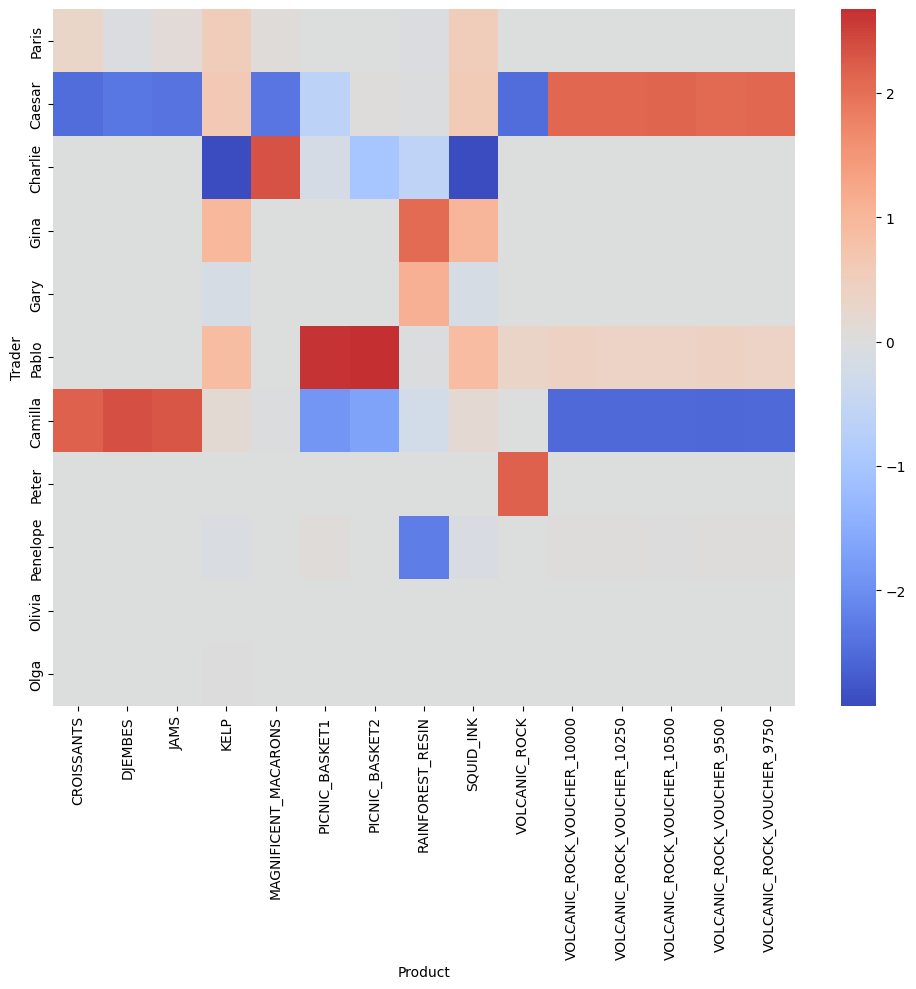

In [182]:
# Calculate net pnl stats for each trader
trader_names = trades['seller'].unique()
pnl_dict = {}

for trader in trader_names:
    pnl_data = trader_stats(trader, trades)
    pnl_dict[trader] = pnl_data['net_pnl']

pnl_df = pd.DataFrame(pnl_dict).T.fillna(0)
scaler = StandardScaler()
pnl_df = pd.DataFrame(scaler.fit_transform(pnl_df), columns=pnl_df.columns, index=pnl_df.index)

plt.figure(figsize=(10, 10))
sns.heatmap(pnl_df, cmap='coolwarm', center=0)
plt.xlabel("Product")
plt.ylabel("Trader")
plt.tight_layout()
plt.show()

In [147]:
pablo_stats = trader_stats('Pablo')
pablo_stats

,buy_qty,buy_value,avg_buy_price,sell_qty,sell_value,avg_sell_price,avg_spread,net_pnl
symbol,,,,,,,,
PICNIC_BASKET1,936,54630553.0,58363.523659,1867,108956319.0,58362.483766,-1.039893,54325766.0
PICNIC_BASKET2,638,19211855.0,30111.561321,1971,59337302.0,30105.717308,-5.844013,40125447.0
SQUID_INK,795,1493681.0,1881.371069,2041,3833261.0,1880.791837,-0.579232,2339580.0
KELP,854,1738705.0,2035.674699,1980,4027703.0,2034.200837,-1.473862,2288998.0
VOLCANIC_ROCK_VOUCHER_9500,37,20781.0,569.750000,3803,2165314.0,572.370115,2.620115,2144533.0
VOLCANIC_ROCK_VOUCHER_9750,90,31405.0,359.214286,3785,1227848.0,327.806452,-31.407834,1196443.0
VOLCANIC_ROCK_VOUCHER_10000,26,3877.0,155.000000,3792,464981.0,124.312500,-30.687500,461104.0
VOLCANIC_ROCK,360,3626878.0,10071.500000,388,3907984.0,10074.316327,2.816327,281106.0
VOLCANIC_ROCK_VOUCHER_10250,47,890.0,26.500000,3798,89083.0,24.098851,-2.401149,88193.0


In [191]:
camilla_stats = trader_stats('Camilla')
camilla_stats

,buy_qty,buy_value,avg_buy_price,sell_qty,sell_value,avg_sell_price,avg_spread,net_pnl
symbol,,,,,,,,
JAMS,116,752547.0,6482.190476,7611,49353539.0,6485.371758,3.181282,48600992.0
DJEMBES,1,13365.0,13365.000000,2224,29661051.0,13336.054711,-28.945289,29647686.0
CROISSANTS,21,89220.0,4246.750000,4641,19790129.0,4264.038690,17.288690,19700909.0
SQUID_INK,1575,2957539.0,1881.006143,1817,3416614.0,1879.232009,-1.774134,459075.0
KELP,1506,3063839.0,2033.923077,1682,3424967.0,2036.178447,2.255370,361128.0
MAGNIFICENT_MACARONS,891,620356.0,695.760456,870,607568.0,697.917969,2.157512,-12788.0
VOLCANIC_ROCK_VOUCHER_10500,15642,57066.0,3.551805,140,689.0,5.000000,1.448195,-56377.0
RAINFOREST_RESIN,446,4458662.0,9997.000000,422,4221266.0,10003.000000,6.000000,-237396.0
VOLCANIC_ROCK_VOUCHER_10250,24423,650428.0,26.557563,1155,53495.0,46.460674,19.903111,-596933.0


In [193]:
caesar_stats = trader_stats('Caesar')
caesar_stats

,buy_qty,buy_value,avg_buy_price,sell_qty,sell_value,avg_sell_price,avg_spread,net_pnl
symbol,,,,,,,,
VOLCANIC_ROCK_VOUCHER_9500,1026,585219.0,574.584187,20960,11956642.0,571.874704,-2.709483,11371423.0
VOLCANIC_ROCK_VOUCHER_9750,1010,333674.0,331.658960,21627,7061654.0,328.024862,-3.634098,6727980.0
VOLCANIC_ROCK_VOUCHER_10000,952,125432.0,131.208841,21786,2691658.0,125.341351,-5.867491,2566226.0
KELP,587,1194924.0,2035.508816,1393,2834715.0,2035.349328,-0.159488,1639791.0
SQUID_INK,598,1126297.0,1877.867500,1408,2652058.0,1879.341223,1.473723,1525761.0
PICNIC_BASKET2,523,15745308.0,30107.827586,540,16260991.0,30116.703470,8.875884,515683.0
VOLCANIC_ROCK_VOUCHER_10250,866,22638.0,27.529204,20204,524670.0,26.399288,-1.129916,502032.0
VOLCANIC_ROCK_VOUCHER_10500,826,2225.0,3.583333,12493,50007.0,3.988401,0.405068,47782.0
RAINFOREST_RESIN,675,6748742.0,9998.552174,672,6721336.0,10001.467480,2.915306,-27406.0


In [201]:
trades['seller']=='Caesar'

0        False
1        False
2         True
3         True
4        False
         ...  
53472    False
53473    False
53474    False
53475     True
53476    False
Name: seller, Length: 53477, dtype: bool

In [203]:
trades['symbol']=='VOLCANIC_ROCK_VOUCHER_10000'

0        False
1        False
2        False
3        False
4        False
         ...  
53472    False
53473    False
53474    False
53475    False
53476    False
Name: symbol, Length: 53477, dtype: bool

In [216]:
prices[prices['timestamp'] == 31800]

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
4770,2,31800,VOLCANIC_ROCK_VOUCHER_10500,6.0,0.0,NaN,NaN,NaN,NaN,7.0,17.0,NaN,NaN,NaN,NaN,6.5,0.0
4771,2,31800,DJEMBES,13432.0,64.0,NaN,NaN,NaN,NaN,13434.0,64.0,NaN,NaN,NaN,NaN,13433.0,0.0
4772,2,31800,MAGNIFICENT_MACARONS,665.0,14.0,662.0,16.0,656.0,29.0,674.0,7.0,683.0,29.0,689.0,16.0,669.5,0.0
4773,2,31800,VOLCANIC_ROCK,10181.0,205.0,NaN,NaN,NaN,NaN,10183.0,134.0,10184.0,71.0,NaN,NaN,10182.0,0.0
4774,2,31800,CROISSANTS,4268.0,59.0,4267.0,92.0,NaN,NaN,4269.0,151.0,NaN,NaN,NaN,NaN,4268.5,0.0
4775,2,31800,SQUID_INK,1775.0,1.0,1774.0,29.0,NaN,NaN,1777.0,1.0,1778.0,29.0,NaN,NaN,1776.0,0.0
4776,2,31800,RAINFOREST_RESIN,9992.0,31.0,NaN,NaN,NaN,NaN,10008.0,31.0,NaN,NaN,NaN,NaN,10000.0,0.0
4777,2,31800,VOLCANIC_ROCK_VOUCHER_9500,682.0,0.0,NaN,NaN,NaN,NaN,683.0,17.0,NaN,NaN,NaN,NaN,682.5,0.0
4778,2,31800,PICNIC_BASKET2,30089.0,1.0,30088.0,36.0,NaN,NaN,30094.0,1.0,30095.0,36.0,NaN,NaN,30091.5,0.0
4779,2,31800,VOLCANIC_ROCK_VOUCHER_9750,435.0,0.0,NaN,NaN,NaN,NaN,436.0,17.0,NaN,NaN,NaN,NaN,435.5,0.0


In [219]:
prices[prices['product'] == 'VOLCANIC_ROCK_VOUCHER_10500']

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
13,2,0,VOLCANIC_ROCK_VOUCHER_10500,8.0,11.0,NaN,NaN,NaN,NaN,9.0,11.0,NaN,NaN,NaN,NaN,8.5,0.0
15,2,100,VOLCANIC_ROCK_VOUCHER_10500,8.0,19.0,NaN,NaN,NaN,NaN,9.0,19.0,NaN,NaN,NaN,NaN,8.5,0.0
38,2,200,VOLCANIC_ROCK_VOUCHER_10500,9.0,15.0,NaN,NaN,NaN,NaN,10.0,15.0,NaN,NaN,NaN,NaN,9.5,0.0
57,2,300,VOLCANIC_ROCK_VOUCHER_10500,9.0,16.0,NaN,NaN,NaN,NaN,10.0,16.0,NaN,NaN,NaN,NaN,9.5,0.0
68,2,400,VOLCANIC_ROCK_VOUCHER_10500,8.0,16.0,NaN,NaN,NaN,NaN,9.0,16.0,NaN,NaN,NaN,NaN,8.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449930,4,999500,VOLCANIC_ROCK_VOUCHER_10500,0.0,15.0,NaN,NaN,NaN,NaN,2.0,15.0,NaN,NaN,NaN,NaN,1.0,0.0
449947,4,999600,VOLCANIC_ROCK_VOUCHER_10500,0.0,14.0,NaN,NaN,NaN,NaN,2.0,14.0,NaN,NaN,NaN,NaN,1.0,0.0
449964,4,999700,VOLCANIC_ROCK_VOUCHER_10500,0.0,16.0,NaN,NaN,NaN,NaN,2.0,16.0,NaN,NaN,NaN,NaN,1.0,0.0
449981,4,999800,VOLCANIC_ROCK_VOUCHER_10500,0.0,22.0,NaN,NaN,NaN,NaN,2.0,22.0,NaN,NaN,NaN,NaN,1.0,0.0


In [209]:
trades[(trades['seller'] == 'Caesar') & (trades['buyer'] == 'Caesar')]

,timestamp,buyer,seller,symbol,currency,price,quantity,trade_value,seller_pnl,buyer_pnl
39,3500,Caesar,Caesar,VOLCANIC_ROCK_VOUCHER_10000,SEASHELLS,234.0,2,468.0,468.0,-468.0
41,3500,Caesar,Caesar,VOLCANIC_ROCK_VOUCHER_10250,SEASHELLS,64.0,2,128.0,128.0,-128.0
43,3500,Caesar,Caesar,VOLCANIC_ROCK_VOUCHER_10500,SEASHELLS,9.0,2,18.0,18.0,-18.0
45,3500,Caesar,Caesar,VOLCANIC_ROCK_VOUCHER_9500,SEASHELLS,722.0,2,1444.0,1444.0,-1444.0
47,3500,Caesar,Caesar,VOLCANIC_ROCK_VOUCHER_9750,SEASHELLS,473.0,2,946.0,946.0,-946.0
...,...,...,...,...,...,...,...,...,...,...
53358,993600,Caesar,Caesar,VOLCANIC_ROCK_VOUCHER_9750,SEASHELLS,368.0,2,736.0,736.0,-736.0
53411,996300,Caesar,Caesar,VOLCANIC_ROCK,SEASHELLS,10110.0,8,80880.0,80880.0,-80880.0
53434,998300,Caesar,Caesar,VOLCANIC_ROCK_VOUCHER_10000,SEASHELLS,123.0,1,123.0,123.0,-123.0
53436,998300,Caesar,Caesar,VOLCANIC_ROCK_VOUCHER_10250,SEASHELLS,10.0,1,10.0,10.0,-10.0


In [208]:
trades[(trades['seller'] == 'Caesar') & (trades['symbol'] == 'VOLCANIC_ROCK_VOUCHER_10000')]

,timestamp,buyer,seller,symbol,currency,price,quantity,trade_value,seller_pnl,buyer_pnl
38,3500,Camilla,Caesar,VOLCANIC_ROCK_VOUCHER_10000,SEASHELLS,234.0,14,3276.0,3276.0,-3276.0
39,3500,Caesar,Caesar,VOLCANIC_ROCK_VOUCHER_10000,SEASHELLS,234.0,2,468.0,468.0,-468.0
109,7600,Camilla,Caesar,VOLCANIC_ROCK_VOUCHER_10000,SEASHELLS,238.0,13,3094.0,3094.0,-3094.0
175,12500,Camilla,Caesar,VOLCANIC_ROCK_VOUCHER_10000,SEASHELLS,215.0,18,3870.0,3870.0,-3870.0
215,15000,Camilla,Caesar,VOLCANIC_ROCK_VOUCHER_10000,SEASHELLS,212.0,17,3604.0,3604.0,-3604.0
...,...,...,...,...,...,...,...,...,...,...
53418,996700,Camilla,Caesar,VOLCANIC_ROCK_VOUCHER_10000,SEASHELLS,128.0,11,1408.0,1408.0,-1408.0
53433,998300,Camilla,Caesar,VOLCANIC_ROCK_VOUCHER_10000,SEASHELLS,123.0,11,1353.0,1353.0,-1353.0
53434,998300,Caesar,Caesar,VOLCANIC_ROCK_VOUCHER_10000,SEASHELLS,123.0,1,123.0,123.0,-123.0
53457,999300,Penelope,Caesar,VOLCANIC_ROCK_VOUCHER_10000,SEASHELLS,123.0,1,123.0,123.0,-123.0


In [ ]:
# CHECK EVERYONES PNL OR SEE CORRELATION BETWEEN TRADER AND PRICE?
# ALSO CHECK HOW MUCH SOMEONE ALWAYS TRADES I.E. CAMILLA MAYBE ALWAYS TRADES X% ABOVE OR BELOW THE PRICEx

In [76]:
# Drop bid/ask columns from trades df so we can merge 
trades_clean = trades.drop(columns=['bid_price_1','ask_price_1'], errors=True)

# Retrieve best bid/ask and sort in ascending order
prices_q = prices[['timestamp','bid_price_1','ask_price_1']].sort_values('timestamp')
# Match trades to prices using the timestamp
matched_trades = pd.merge_asof(trades_clean.sort_values('timestamp'), prices_q, on='timestamp', direction='backward')

# Compare trade price to bid/ask - check how aggressive or passive the trade was (aggressive if you cross spread and take liquidity away, passive if you add liquidity and wait)
matched_trades['qtyAgsBuy']  = np.where(matched_trades.price == matched_trades.ask_price_1, matched_trades.quantity, 0)
matched_trades['qtyPsvBuy']  = np.where(matched_trades.price != matched_trades.ask_price_1, matched_trades.quantity, 0)
matched_trades['qtyAgsSell'] = np.where(matched_trades.price == matched_trades.bid_price_1, matched_trades.quantity, 0)
matched_trades['qtyPsvSell'] = np.where(matched_trades.price != matched_trades.bid_price_1, matched_trades.quantity, 0)

# Split buy side/sell side trades by trader and product
buy  = matched_trades.groupby(['buyer','symbol'])[['qtyAgsBuy','qtyPsvBuy']].sum()
sell = matched_trades.groupby(['seller','symbol'])[['qtyAgsSell','qtyPsvSell']].sum()

# Concat and fill nan with 0
result = (pd.concat([buy, sell], axis=1, sort=False)
            .fillna(0)
            .rename_axis(index={'buyer':'trader','seller':'trader', 'symbol':'product'})
            .reset_index())

# Sort by product alphabetically
result.columns = ['trader', 'product', 'qtyAgsBuy', 'qtyPsvBuy', 'qtyAgsSell', 'qtyPsvSell']
# result = result.sort_values(by=['product', 'trader'])
result = result.sort_values(by=['qtyPsvBuy', 'qtyPsvSell'], ascending=False)  # Sort by passive
# result = result.sort_values(by=['qtyAgsBuy', 'qtyAgsSell'], ascending=False)  # Sort by aggressive

result

,trader,product,qtyAgsBuy,qtyPsvBuy,qtyAgsSell,qtyPsvSell
28,Camilla,VOLCANIC_ROCK_VOUCHER_9750,0.0,29559.0,0,4808
27,Camilla,VOLCANIC_ROCK_VOUCHER_9500,11.0,28856.0,12,4749
24,Camilla,VOLCANIC_ROCK_VOUCHER_10000,14.0,28359.0,0,3380
25,Camilla,VOLCANIC_ROCK_VOUCHER_10250,63.0,24360.0,0,1155
2,Caesar,JAMS,0.0,16280.0,6,8433
...,...,...,...,...,...,...
50,Pablo,VOLCANIC_ROCK_VOUCHER_10000,0.0,26.0,8,3784
15,Camilla,CROISSANTS,0.0,21.0,0,4641
41,Olivia,CROISSANTS,0.0,9.0,0,9
16,Camilla,DJEMBES,0.0,1.0,0,2224
